# Image Classification Using Deep Learning — Part 01
---

> **A beginner-friendly notebook** exploring image classification on the classic **MNIST handwritten digit dataset** using PyTorch — covering data loading, transformation, batching, and visualization.

---

## Topics are covered

| # | Topic | Tool/Concept |
|---|-------|-------------|
| 1 | Import Dataset | `torchvision.datasets` |
| 2 | Apply Transforms | `transforms.ToTensor()` |
| 3 | Batch Loading | `torch.utils.data.DataLoader` |
| 4 | Inspect Data Shape | Tensor shape analysis |
| 5 | Visualize Sample | `matplotlib` |

---

##  Libraries Used
- `torch` — core deep learning framework
- `torchvision` — datasets and image transforms
- `matplotlib` — image visualization

## Step 1 — Import torchvision

`torchvision` is PyTorch's companion library for computer vision.
It provides ready-to-use **benchmark datasets** (MNIST, CIFAR, ImageNet),
**transforms** for preprocessing, and pretrained model architectures.

In [1]:
# Import datasets and transforms from torchvision
from torchvision import datasets, transforms

##Step 2 — Load MNIST Dataset with Transform

### What is MNIST?

**MNIST** is a classic benchmark dataset of **70,000 grayscale images** of handwritten digits (0–9),
each of size **28×28 pixels**.

| Property | Value |
|----------|-------|
| Total samples | 70,000 |
| Training samples | 60,000 |
| Test samples | 10,000 |
| Image size | 28 × 28 pixels |
| Classes | 10 (digits 0–9) |
| Color | Grayscale |

### What does `transforms.ToTensor()` do?

It converts a PIL image into a **PyTorch tensor** and scales pixel values from
the range $[0, 255]$ to $[0.0, 1.0]$:

$$\text{tensor\_value} = \frac{\text{pixel\_value}}{255}$$

This normalization helps the model train faster and more stably.

In [2]:
# Define transform: convert images to tensors (scales pixels to [0, 1])
transform = transforms.ToTensor()

# Download and load the MNIST training dataset
mnist_dataset = datasets.MNIST(
    root='./data',      # folder where data will be saved
    train=True,         # load training set (60,000 images)
    download=True,      # download if not already present
    transform=transform # apply the ToTensor transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 583kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.42MB/s]



## Step 3 — Create a DataLoader

### What is a DataLoader?

A `DataLoader` wraps a dataset and provides:
- **Batching** — groups samples into mini-batches
- **Shuffling** — randomizes order each epoch to improve training
- **Iteration** — easy `for` loop access to batches

### Why batch_size=10?

Instead of feeding all 60,000 images at once (too much memory),
we feed **10 images at a time**. This is called **mini-batch gradient descent**.

$$\text{Total batches} = \frac{60000}{10} = 6000 \text{ batches per epoch}$$

In [3]:
from torch.utils.data import DataLoader

# Wrap dataset in DataLoader for batching and shuffling
loader = DataLoader(
    mnist_dataset,
    batch_size=10,   # load 10 images per batch
    shuffle=True     # shuffle data every epoch
)


## Step 4 — Inspect Batch Shape

We grab the **first batch** from the loader using `next(iter(...))` and inspect the tensor shapes.

### Understanding the shape: `[10, 1, 28, 28]`

| Dimension | Value | Meaning |
|-----------|-------|---------|
| `10` | batch size | 10 images per batch |
| `1` | channels | grayscale = 1 channel (RGB would be 3) |
| `28` | height | 28 pixels tall |
| `28` | width | 28 pixels wide |

The labels shape `[10]` means one integer label (0–9) for each of the 10 images.

In [4]:
# Grab the first batch from the loader
images, labels = next(iter(loader))

# images shape: [batch_size, channels, height, width]
print(images.shape)

# labels shape: [batch_size] — one digit label per image
print(labels.shape)

torch.Size([10, 1, 28, 28])
torch.Size([10])




## Step 5 — Visualize a Random Sample

We pick a **random image** from the batch and display it using `matplotlib`.

- `image.squeeze()` removes the channel dimension `[1, 28, 28]` → `[28, 28]`
  so matplotlib can display it as a 2D image
- `cmap='gray'` renders it in grayscale
- The title shows the **true label** (the actual digit)

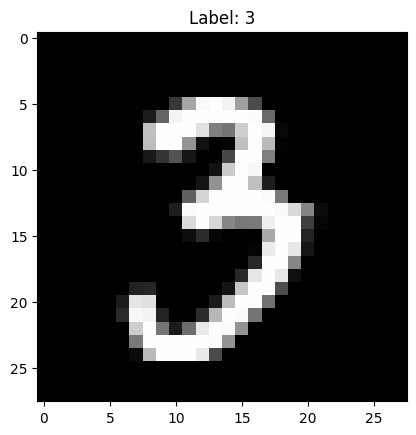

In [9]:
import random
import matplotlib.pyplot as plt

# Pick a random index from the batch (0 to 9)
random_idx = random.randint(0, 9)
image = images[random_idx]
label = labels[random_idx]

# squeeze() removes the channel dim: [1, 28, 28] → [28, 28]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label.item()}")
plt.show()


##  Conclusion

###  Summary

| Step | Action | Key Detail |
|------|--------|------------|
| Step 1 | Imported torchvision | Access to datasets & transforms |
| Step 2 | Loaded MNIST dataset | 60,000 training images, 28×28 grayscale |
| Step 3 | Created DataLoader | batch_size=10, shuffle=True |
| Step 4 | Inspected tensor shape | `[10, 1, 28, 28]` — batch × channel × H × W |
| Step 5 | Visualized a sample | Random image with true digit label |

---

###  Key Takeaways

1. **`transforms.ToTensor()`** converts images to tensors and normalizes pixels to $[0, 1]$
2. **DataLoader** handles batching and shuffling — essential for efficient training
3. **MNIST tensor shape** `[B, C, H, W]` is the standard format in PyTorch (Batch, Channel, Height, Width)
4. **Grayscale images** have 1 channel; RGB images have 3 channels
5. This notebook is **Part 01** — data loading and visualization before model building begins
